# Face Recognition

A face recognition system is trained to identify 40 different subjects using the **Olivetti Faces Dataset** (400 grayscale 64x64 images, 10 per subject).

The approach follows the classic **Eigenfaces + Nearest Neighbors** pipeline:
1. Images are flattened and normalized
2. PCA extracts the principal components (eigenfaces), reducing dimensionality
3. A KNN classifier operates in the eigenface space

Finally, the photo `me.jpeg` is loaded and the most visually similar subject in the dataset is identified.

In [100]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)

RANDOM_SEED  = 0
DATA_DIR     = "datasets/olivetti_faces"
# ME_PATH      = "datasets/me.jpeg"
IMAGE_SIZE   = (64, 64)

## Step 1 - Data Loading

Images are loaded from the folder structure `olivetti_faces/<subject_id>/<img_id>.jpg`.
Each subject has 10 grayscale 64x64 images. Pixel values are normalized to [0, 1].

In [101]:
images = []
labels = []

subject_ids = sorted(os.listdir(DATA_DIR), key=lambda x: int(x))
n_subjects  = len(subject_ids)

for subject in subject_ids:
    subject_path = os.path.join(DATA_DIR, subject)
    if not os.path.isdir(subject_path):
        continue
    for img_file in sorted(os.listdir(subject_path)):
        img_path = os.path.join(subject_path, img_file)
        img = Image.open(img_path).convert("L").resize(IMAGE_SIZE)
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(int(subject))

X = np.array(images).reshape(len(images), -1)   # shape: (400, 4096)
y = np.array(labels)

print(f"Dataset: {X.shape[0]} images, {n_subjects} subjects")
print(f"Feature matrix shape: {X.shape}")
print(f"Pixel range: [{X.min():.2f}, {X.max():.2f}]")

Dataset: 400 images, 40 subjects
Feature matrix shape: (400, 4096)
Pixel range: [0.00, 1.00]


## Step 2 - Exploratory Data Analysis

The first 5 images for each of the 40 subjects are displayed to get a visual overview of the dataset.

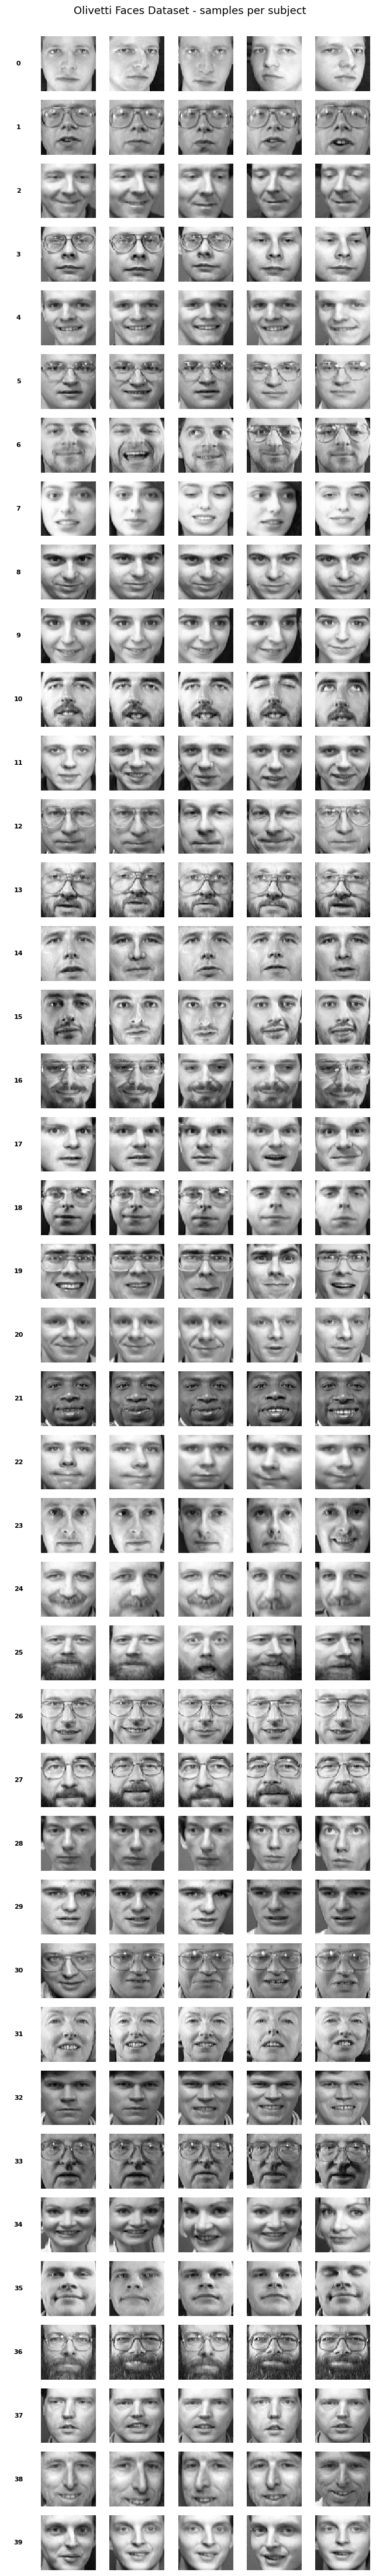

In [102]:
n_show = 5
n_cols = n_show + 1   # extra col for subject label

fig, axes = plt.subplots(
    n_subjects, n_cols,
    figsize=(n_cols * 1.1, n_subjects * 1.1),
    gridspec_kw={"width_ratios": [0.4] + [1] * n_show},
)
fig.suptitle("Olivetti Faces Dataset - samples per subject", fontsize=13, y=1.001)

for subj_idx, subj in enumerate(range(n_subjects)):
    mask      = y == subj
    subj_imgs = X[mask][:n_show]

    # label column
    axes[subj_idx, 0].text(0.5, 0.5, str(subj), ha="center", va="center",
                           fontsize=8, fontweight="bold")
    axes[subj_idx, 0].axis("off")

    for j in range(n_show):
        axes[subj_idx, j + 1].imshow(subj_imgs[j].reshape(64, 64),
                                      cmap="gray", interpolation="nearest")
        axes[subj_idx, j + 1].axis("off")

plt.tight_layout()
plt.show()

## Step 3 - Preprocessing and train/test split

The dataset is split into train (80%) and test (20%) with per-subject stratification.
Normalization to [0, 1] is already applied during loading.

**PCA (Eigenfaces)** is applied to reduce dimensionality from 4096 features to a compact set of components:
- Eigenfaces capture the directions of maximum variance in image space
- The number of components is chosen to explain 95% of total variance

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED,
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# --- PCA (Eigenfaces) ---
pca = PCA(n_components=0.95, whiten=True, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

n_components = pca.n_components_
explained    = pca.explained_variance_ratio_.cumsum()[-1]
print(f"\nPCA: {n_components} components explain {explained * 100:.1f}% of variance")
print(f"Dimensionality reduction: 4096 -> {n_components}")

Train: 320 samples | Test: 80 samples

PCA: 112 components explain 95.0% of variance
Dimensionality reduction: 4096 -> 112


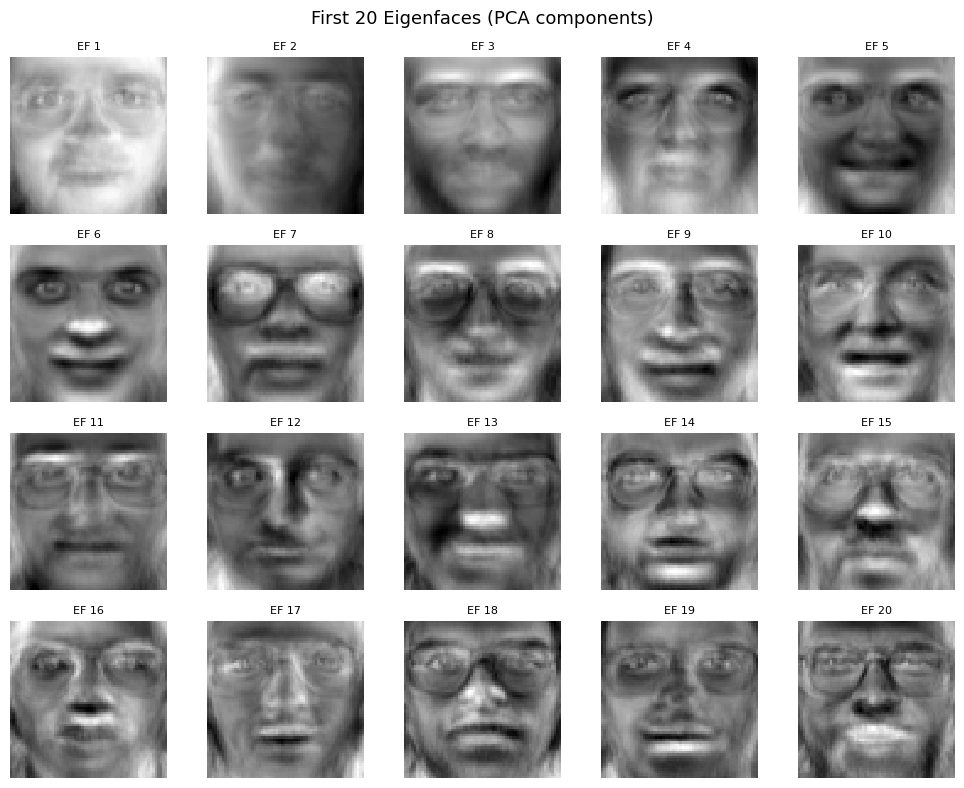

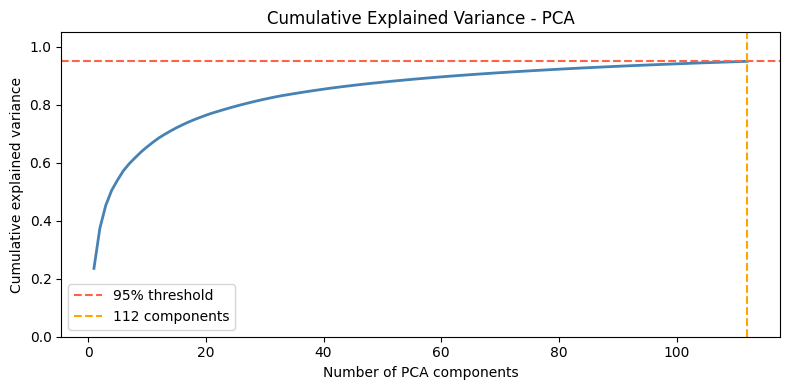

In [104]:
# First 20 eigenfaces
n_eigen_show = 20
eigenfaces   = pca.components_[:n_eigen_show].reshape((n_eigen_show, 64, 64))

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle("First 20 Eigenfaces (PCA components)", fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap="gray", interpolation="nearest")
    ax.set_title(f"EF {i + 1}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cumvar) + 1), cumvar, color="steelblue", lw=2)
ax.axhline(0.95, color="tomato", linestyle="--", label="95% threshold")
ax.axvline(n_components, color="orange", linestyle="--", label=f"{n_components} components")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative Explained Variance - PCA")
ax.legend()
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

## Step 4 - KNN Hyperparameter Tuning

The number of neighbors `k` is the key parameter for KNN. Cross-validation accuracy on the training set is evaluated for k from 1 to 15, and the optimal value is selected.

Best k: 1  (CV accuracy: 0.7875)


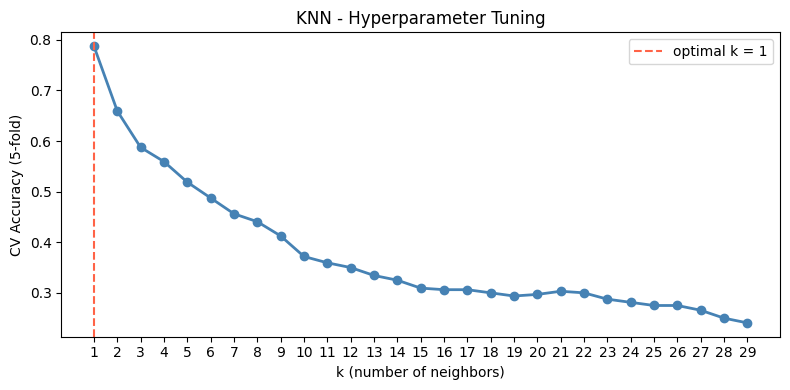

In [105]:
k_values  = range(1, 30)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k}  (CV accuracy: {max(cv_scores):.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_values), cv_scores, marker="o", color="steelblue", lw=2)
ax.axvline(best_k, color="tomato", linestyle="--", label=f"optimal k = {best_k}")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("CV Accuracy (5-fold)")
ax.set_title("KNN - Hyperparameter Tuning")
ax.legend()
ax.set_xticks(list(k_values))
plt.tight_layout()
plt.show()

## Step 5 - Model Training

The KNN classifier is trained with the optimal k found in the previous step.

In [106]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn.fit(X_train_pca, y_train)

train_acc = accuracy_score(y_train, knn.predict(X_train_pca))
test_acc  = accuracy_score(y_test,  knn.predict(X_test_pca))

print(f"Train Accuracy : {train_acc:.4f} ({train_acc * 100:.1f}%)")
print(f"Test  Accuracy : {test_acc:.4f} ({test_acc * 100:.1f}%)")
print(f"\nTarget >= 80%: {'OK' if test_acc >= 0.80 else 'NOT REACHED'}")

Train Accuracy : 1.0000 (100.0%)
Test  Accuracy : 0.8375 (83.8%)

Target >= 80%: OK


## Step 6 - Model Evaluation

The classification report and confusion matrix are shown for the test set.

Classification Report (Test Set)
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       1.00      0.50      0.67         2
           8       0.67      1.00      0.80         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.33      1.00      0.50         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00     

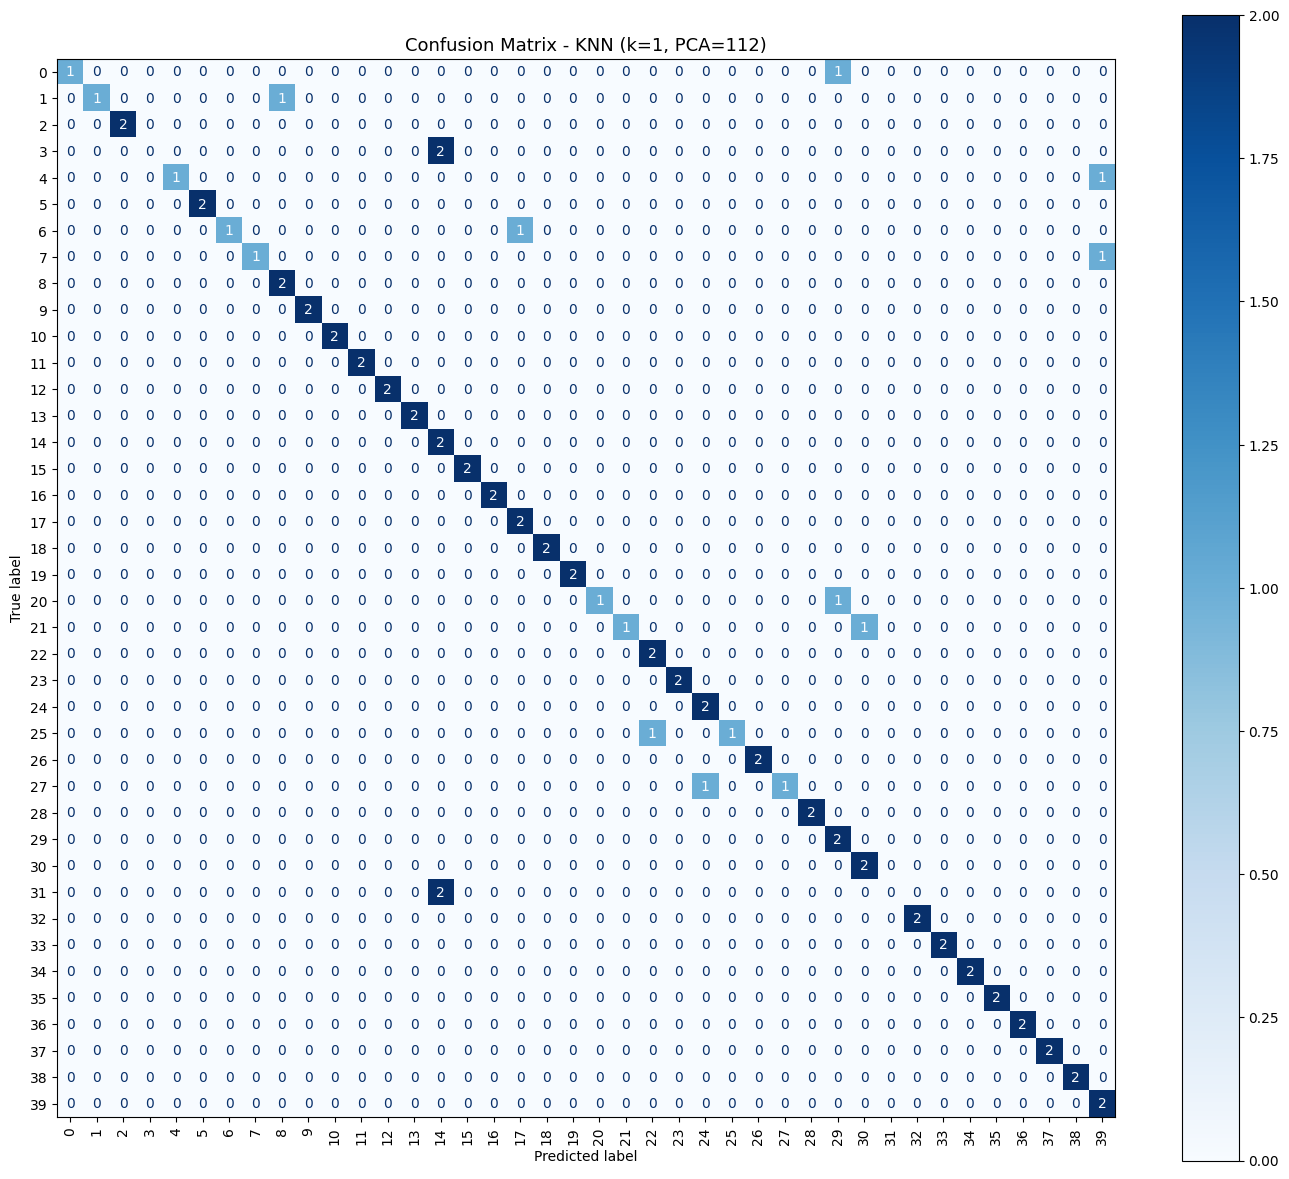

In [107]:
y_pred = knn.predict(X_test_pca)

print("Classification Report (Test Set)")
print("=" * 55)
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=range(n_subjects))

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(n_subjects))
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=90)
ax.set_title(f"Confusion Matrix - KNN (k={best_k}, PCA={n_components})", fontsize=13)
plt.tight_layout()
plt.show()

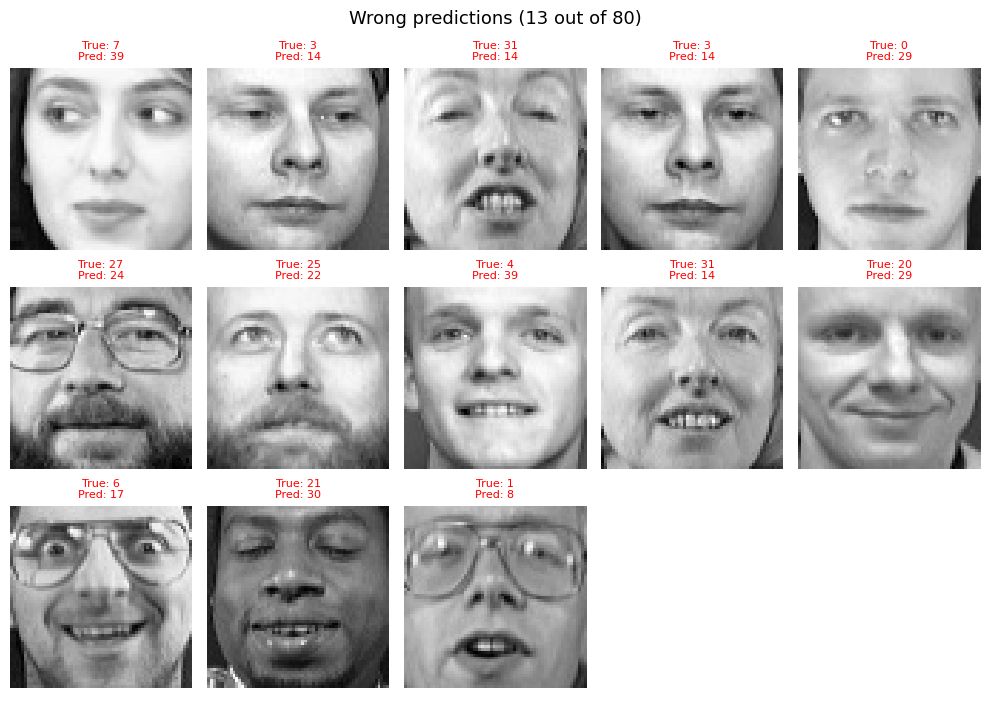

In [108]:
# Wrong predictions
wrong_mask    = y_pred != y_test
wrong_indices = np.where(wrong_mask)[0]

if len(wrong_indices) == 0:
    print("No wrong predictions on the test set.")
else:
    n_wrong = min(20, len(wrong_indices))
    n_cols  = 5
    n_rows  = (n_wrong + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
    axes = axes.flat
    fig.suptitle(f"Wrong predictions ({len(wrong_indices)} out of {len(y_test)})", fontsize=13)

    for i, idx in enumerate(wrong_indices[:n_wrong]):
        ax = axes[i]
        ax.imshow(X_test[idx].reshape(64, 64), cmap="gray", interpolation="nearest")
        ax.set_title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}", fontsize=8, color="red")
        ax.axis("off")

    for j in range(n_wrong, n_rows * n_cols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

## Step 7 - Who looks most similar?

The photo `me.jpeg` is preprocessed (grayscale, resized to 64x64, normalized) and projected into the eigenface space. KNN identifies the nearest neighbors in the dataset, revealing the most similar Olivetti subject.

In [109]:
## --- Load and preprocess me.jpeg ---
#me_img  = Image.open(ME_PATH).convert("L").resize(IMAGE_SIZE)
#me_arr  = np.array(me_img, dtype=np.float32) / 255.0
#me_flat = me_arr.reshape(1, -1)
#me_pca  = pca.transform(me_flat)
#
## --- Prediction and distances over the full dataset ---
#X_all_pca = pca.transform(X)
#
#distances  = np.linalg.norm(X_all_pca - me_pca, axis=1)
#top_n      = 5
#top_idx    = np.argsort(distances)[:top_n]
#top_labels = y[top_idx]
#top_dists  = distances[top_idx]
#
#predicted_subject = knn.predict(me_pca)[0]
#print(f"Most similar subject (KNN predict): {predicted_subject}")
#print(f"\nTop {top_n} nearest neighbors:")
#for rank, (idx, lbl, dist) in enumerate(zip(top_idx, top_labels, top_dists), 1):
#    print(f"  {rank}. Subject {lbl:2d} | distance: {dist:.4f}")

In [ ]:
# # --- me.jpeg vs best matching subject ---
# best_subj      = predicted_subject
# best_subj_imgs = X[y == best_subj]
#
# n_best_show = min(5, len(best_subj_imgs))
# fig, axes   = plt.subplots(1, n_best_show + 1, figsize=((n_best_show + 1) * 2.2, 3))
# fig.suptitle(f"Comparison: me.jpeg vs Subject {best_subj} (closest match)", fontsize=12)
#
# axes[0].imshow(me_arr, cmap="gray", interpolation="nearest")
# axes[0].set_title("me.jpeg", fontsize=10, fontweight="bold", color="steelblue")
# axes[0].axis("off")
#
# for j in range(n_best_show):
#     axes[j + 1].imshow(best_subj_imgs[j].reshape(64, 64), cmap="gray", interpolation="nearest")
#     axes[j + 1].set_title(f"Subject {best_subj}\n(img {j})", fontsize=9)
#     axes[j + 1].axis("off")
#
# plt.tight_layout()
# plt.show()
#
# # --- Top 5 nearest subjects ---
# fig, axes = plt.subplots(1, top_n + 1, figsize=((top_n + 1) * 2.2, 3))
# fig.suptitle(f"Top {top_n} most similar subjects to me.jpeg (Euclidean distance in PCA space)", fontsize=11)
#
# axes[0].imshow(me_arr, cmap="gray", interpolation="nearest")
# axes[0].set_title("me.jpeg", fontsize=10, fontweight="bold", color="steelblue")
# axes[0].axis("off")
#
# for rank, (idx, lbl, dist) in enumerate(zip(top_idx, top_labels, top_dists)):
#     axes[rank + 1].imshow(X[idx].reshape(64, 64), cmap="gray", interpolation="nearest")
#     axes[rank + 1].set_title(f"#{rank + 1} Subj. {lbl}\nd={dist:.3f}", fontsize=8)
#     axes[rank + 1].axis("off")
#
# plt.tight_layout()
# plt.show()

## Conclusions

**Key takeaways:**

- The **Eigenfaces + KNN** pipeline drastically reduces dimensionality while retaining discriminative information, improving both accuracy and KNN runtime.
- PCA whitening equalizes component variances, making Euclidean distance in the PCA space more meaningful for face comparison.
- Selecting the optimal k via cross-validation prevents overfitting to the training set.
- The similarity match with `me.jpeg` is based on Euclidean distance in eigenface space: the subject with the smallest distance is the most similar in terms of facial structure captured by the leading PCA components.